In [1]:
!nvidia-smi

Sat May 23 00:40:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   37C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics -q

In [8]:
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-distutils -y
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3.10 get-pip.py

# Upgrade setuptools to a compatible version
!python3.10 -m pip install --upgrade setuptools


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-distutils' instead of 'python3.10-distutils'
python3-distutils is already the newest version (3.10.8-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 66 not upgraded.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2174k  100 2174k    0     0  17.8M      0 --:--:-- --:--:-- --:--:-- 17.9M
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.2 MB/s  0:00:00
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [wheel]


In [9]:
!python3.10 -m pip --version

pip 26.1.1 from /usr/local/lib/python3.10/dist-packages/pip (python 3.10)


In [19]:
!python3.10 -m pip install "setuptools<70.0.0" wheel cython
!python3.10 -m pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu121
!python3.10 -m pip install chumpy --no-build-isolation
!python3.10 -m pip install mmengine
!python3.10 -m pip install mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1.0/index.html
!python3.10 -m pip install mmpose

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 24.9 MB/s  0:00:19
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 180.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 151.6 MB/s  0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.7.0
    Uninstalling triton-3.7.0:
      Successfully uninstalled triton-3.7.0
  Attempting uninstall: torch
    Found existing installation: torch 2.12.0
    Uninstalling torch-2.12.0:
      Successfully uninstalled torch-2.12.0
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.27.0
    Uninstalling torchvision-0.27.0:
      Successfully uninstalled torchvision-0.27.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision]
Looking in links: https://download.openmmlab.com/mmcv/dist/cu121/torch2.1.0/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 MB 21.7 MB/s  0:00:04
  At

In [31]:
from google.colab import drive
drive.mount('/content/drive')

import csv, json, time
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE      = '/content/drive/MyDrive/Models/Ohm-Vision'
YOLO_DATA  = f'{DRIVE}/Datasets/yolo-pose'
COCO_DATA  = f'{DRIVE}/Datasets/coco-pose'   # COCO JSON สำหรับ MMPose
OUT        = f'{DRIVE}/Pose-Training-Results'
Path(OUT).mkdir(parents=True, exist_ok=True)

# ── Fair Comparison Constants (fixed สำหรับทุกโมเดล) ─────────────────────────
MAX_EPOCHS = 100
PATIENCE   = 20      # early stop หาก metric ไม่ดีขึ้นใน N epochs
BATCH      = 32
SEED       = 42
LR0        = 1e-3

# ── Custom keypoint meta (2 จุด: ปลายตัวต้านทาน) ──────────────────────────────
KPT_META = dict(
    dataset_name = 'ohm_vision',
    paper_info   = dict(),
    keypoint_info = {
        0: dict(name='body_0', id=0, color=[0,255,0], type='lower', swap='body_1'),
        1: dict(name='body_1', id=1, color=[0,255,0], type='upper', swap='body_0'),
    },
    skeleton_info = {0: dict(link=('body_0','body_1'), id=0, color=[0,255,0])},
    joint_weights = [1., 1.],
    sigmas        = [0.025, 0.025],
)

# ── Metrics helper (บันทึกผลทุกโมเดลลง comparison.csv) ────────────────────────
_CSV    = f'{OUT}/comparison.csv'
_FIELDS = ['model','pose_AP50','pose_AP50_95','box_AP50','box_AP50_95',
           'params_M','size_MB','stopped_epoch','train_min','inf_ms_GPU']

def save_metrics(model_name, pose_ap50, pose_ap50_95,
                 box_ap50='N/A', box_ap50_95='N/A',
                 params_m=0, size_mb=0, stopped_epoch=0, train_min=0, inf_ms=0):
    row = dict(
        model        = model_name,
        pose_AP50    = round(float(pose_ap50), 4),
        pose_AP50_95 = round(float(pose_ap50_95), 4),
        box_AP50     = box_ap50 if isinstance(box_ap50, str) else round(float(box_ap50), 4),
        box_AP50_95  = box_ap50_95 if isinstance(box_ap50_95, str) else round(float(box_ap50_95), 4),
        params_M     = round(params_m, 2),
        size_MB      = round(size_mb, 2),
        stopped_epoch= stopped_epoch,
        train_min    = round(train_min, 1),
        inf_ms_GPU   = round(inf_ms, 2),
    )
    write_header = not Path(_CSV).exists()
    with open(_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=_FIELDS)
        if write_header: w.writeheader()
        w.writerow(row)
    print(f"✓ {model_name}: pose_AP50={pose_ap50:.4f}  pose_AP50_95={pose_ap50_95:.4f}")

print(f"Ready  MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}  BATCH={BATCH}  SEED={SEED}  LR0={LR0}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready  MAX_EPOCHS=100  PATIENCE=20  BATCH=32  SEED=42  LR0=0.001


---
# Dataset

| Format | Path | ใช้กับ |
|---|---|---|
| YOLO pose | `yolo-pose/images/{train,val,test}/` | YOLOv8n |
| COCO JSON | `coco-pose/{train,valid,test}/` | RTMPose, HigherHRNet |

Dataset เดียวกัน แปลง format สองแบบ — split train/val/test ตรงกัน

In [30]:
import yaml

# YOLO pose dataset YAML
data_yaml = dict(
    path      = YOLO_DATA,
    train     = 'images/train',
    val       = 'images/val',
    test      = 'images/test',
    nc        = 2,
    names     = ['resistor', 'wire'],
    kpt_shape = [2, 3],
)
with open(f'{YOLO_DATA}/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("Dataset summary:")
print(f"{'split':8s}  {'YOLO':>6s}  {'COCO':>6s}")
for split, coco_split in [('train','train'),('val','valid'),('test','test')]:
    n_yolo = len(list(Path(f'{YOLO_DATA}/images/{split}').glob('*.*')))
    n_coco = len(list(Path(f'{COCO_DATA}/{coco_split}').glob('*.jpg')) +
                  list(Path(f'{COCO_DATA}/{coco_split}').glob('*.png')))
    print(f"  {split:8s}  {n_yolo:6d}  {n_coco:6d}")
print("✓ data.yaml written")

Dataset summary:
split       YOLO    COCO
  train       1696    1695
  val           66      65
  test          51      50
✓ data.yaml written


---
# Model 1 — YOLOv8n-pose
**Paradigm:** One-stage anchor-free (detection + pose ในขั้นตอนเดียว)  
**Input:** 640×640 full image  
**Params:** ~3.3 M  
**Metric:** Box mAP + Pose mAP (OKS)

In [ ]:
from ultralytics import YOLO
import pandas as pd

_YOLO_DIR = f'{OUT}/yolov8n_pose'

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = YOLO('yolov8n-pose.pt')
model.train(
    data     = f'{YOLO_DATA}/data.yaml',
    epochs   = MAX_EPOCHS,
    patience = PATIENCE,
    imgsz    = 640,
    batch    = BATCH,
    seed     = SEED,
    lr0      = LR0,
    lrf      = 0.01,
    optimizer= 'AdamW',
    cos_lr   = True,
    pose     = 18.0,
    kobj     = 2.0,
    workers  = 4,
    device   = 0,
    project  = OUT,
    name     = 'yolov8n_pose',
    exist_ok = True,
    verbose  = False,
)
train_min = (time.time() - t0) / 60
print(f"Training: {train_min:.1f} min")

# ── Stopped epoch ─────────────────────────────────────────────────────────────
stopped_ep = len(pd.read_csv(f'{_YOLO_DIR}/results.csv'))

# ── Test evaluation ───────────────────────────────────────────────────────────
best = f'{_YOLO_DIR}/weights/best.pt'
model = YOLO(best)
met = model.val(data=f'{YOLO_DATA}/data.yaml', split='test',
                imgsz=640, conf=0.5, iou=0.45, device=0, verbose=False)

# ── Inference speed (GPU) ─────────────────────────────────────────────────────
imgs = list(Path(f'{YOLO_DATA}/images/test').glob('*.jpg'))[:30]
preds = model.predict(imgs, imgsz=640, device=0, verbose=False)
inf_ms = sum(r.speed['inference'] for r in preds) / len(preds)

# ── Model stats ───────────────────────────────────────────────────────────────
params_m = sum(p.numel() for p in YOLO(best).model.parameters()) / 1e6
size_mb  = Path(best).stat().st_size / 1e6

print(f"\n{'='*50}")
print(f"YOLOv8n-pose  epoch={stopped_ep}/{MAX_EPOCHS}  train={train_min:.1f}min")
print(f"  Box  AP50={met.box.map50:.4f}  AP50:95={met.box.map:.4f}")
print(f"  Pose AP50={met.pose.map50:.4f}  AP50:95={met.pose.map:.4f}")
print(f"  {params_m:.2f}M params | {size_mb:.1f}MB | {inf_ms:.2f}ms/img (GPU)")

save_metrics('yolov8n_pose',
    pose_ap50=met.pose.map50, pose_ap50_95=met.pose.map,
    box_ap50=met.box.map50,   box_ap50_95=met.box.map,
    params_m=params_m, size_mb=size_mb,
    stopped_epoch=stopped_ep, train_min=train_min, inf_ms=inf_ms)

---
# Model 2 — RTMPose-s
**Paradigm:** Two-stage Top-Down (detect bbox → crop → pose per instance)  
**Input crop:** 256×192  
**Params:** ~5.1 M  
**Framework:** MMPose 1.x  
**Note:** Evaluation ใช้ GT bbox — แยก detection error ออกจาก pose error (top-down standard)

In [71]:
script_content = f"""
import json, time, csv, torch
from pathlib import Path
from mmengine.runner import Runner
from mmengine.config import Config
from mmpose.apis import init_model, inference_topdown

# ── Inject Variables ────────────────────────────────────────────────────────
OUT        = {repr(OUT)}
COCO_DATA  = {repr(COCO_DATA)}
SEED       = {repr(SEED)}
LR0        = {repr(LR0)}
BATCH      = {repr(BATCH)}
MAX_EPOCHS = {repr(MAX_EPOCHS)}
PATIENCE   = {repr(PATIENCE)}
KPT_META   = {repr(KPT_META)}

def save_metrics(model_name, pose_ap50, pose_ap50_95,
                 box_ap50='N/A', box_ap50_95='N/A',
                 params_m=0, size_mb=0, stopped_epoch=0, train_min=0, inf_ms=0):
    _CSV    = f'{{OUT}}/comparison.csv'
    _FIELDS = ['model','pose_AP50','pose_AP50_95','box_AP50','box_AP50_95',
               'params_M','size_MB','stopped_epoch','train_min','inf_ms_GPU']
    row = dict(
        model        = model_name,
        pose_AP50    = round(float(pose_ap50), 4),
        pose_AP50_95 = round(float(pose_ap50_95), 4),
        box_AP50     = box_ap50 if isinstance(box_ap50, str) else round(float(box_ap50), 4),
        box_AP50_95  = box_ap50_95 if isinstance(box_ap50_95, str) else round(float(box_ap50_95), 4),
        params_M     = round(params_m, 2),
        size_MB      = round(size_mb, 2),
        stopped_epoch= stopped_epoch,
        train_min    = round(train_min, 1),
        inf_ms_GPU   = round(inf_ms, 2),
    )
    write_header = not Path(_CSV).exists()
    with open(_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=_FIELDS)
        if write_header: w.writeheader()
        w.writerow(row)

RTM_DIR = f'{{OUT}}/rtmpose_s'
Path(RTM_DIR).mkdir(parents=True, exist_ok=True)

# ── Shared pipeline components ────────────────────────────────────────────────
_simcc = dict(type='SimCCLabel', input_size=(256,192),
              smoothing_type='gaussian', sigma=(5.66,5.66), simcc_split_ratio=2.0)

train_pipeline = [
    dict(type='LoadImage'),
    dict(type='GetBBoxCenterScale'),
    dict(type='RandomFlip', direction='horizontal'),
    dict(type='RandomBBoxTransform', scale_factor=[0.6,1.4], rotate_factor=80),
    dict(type='TopdownAffine', input_size=(256,192)),
    dict(type='GenerateTarget', encoder=_simcc),
    dict(type='PackPoseInputs')]

val_pipeline = [
    dict(type='LoadImage'),
    dict(type='GetBBoxCenterScale'),
    dict(type='TopdownAffine', input_size=(256,192)),
    dict(type='PackPoseInputs')]

_ds = dict(type='CocoDataset', data_mode='topdown', metainfo=KPT_META)

# ── Full config dict ──────────────────────────────────────────────────────────
rtm_cfg = dict(
    default_scope='mmpose',
    work_dir  = RTM_DIR,
    launcher  = 'none',
    randomness= dict(seed=SEED, deterministic=False),
    env_cfg   = dict(cudnn_benchmark=False,
                     mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0),
                     dist_cfg=dict(backend='nccl')),
    log_level = 'INFO',
    load_from = f'{{RTM_DIR}}/epoch_100.pth',
    resume    = True,

    model=dict(
        type='TopdownPoseEstimator',
        data_preprocessor=dict(
            type='PoseDataPreprocessor',
            mean=[123.675,116.28,103.53], std=[58.395,57.12,57.375],
            bgr_to_rgb=True),
        backbone=dict(
            type='CSPNeXt', arch='P5', expand_ratio=0.5,
            deepen_factor=0.33, widen_factor=0.5, out_indices=(4,),
            channel_attention=True,
            norm_cfg=dict(type='BN'), act_cfg=dict(type='SiLU', inplace=True),
            init_cfg=dict(type='Pretrained', prefix='backbone.',
                checkpoint='https://download.openmmlab.com/mmdetection/v3.0/rtmdet/cspnext_rsb_pretrain/cspnext-s_imagenet_600e.pth')),
        neck=None,
        head=dict(
            type='RTMCCHead', in_channels=512, out_channels=2,
            input_size=(256,192), in_featuremap_size=(8,6),
            simcc_split_ratio=2.0, final_layer_kernel_size=7,
            gau_cfg=dict(hidden_dims=256, s=128, expansion_factor=2,
                dropout_rate=0., drop_path=0., act_fn='SiLU',
                use_rel_bias=False, pos_enc=False),
            loss=dict(type='KLDiscretLoss', use_target_weight=True,
                beta=10., label_softmax=True),
            decoder=_simcc),
        test_cfg=dict(flip_test=True)),

    train_dataloader=dict(
        batch_size=BATCH, num_workers=4, persistent_workers=True,
        sampler=dict(type='DefaultSampler', shuffle=True),
        dataset=dict(**_ds, data_root=COCO_DATA,
            ann_file='train/_annotations.coco.json',
            data_prefix=dict(img='train/'), pipeline=train_pipeline)),

    val_dataloader=dict(
        batch_size=BATCH, num_workers=4, persistent_workers=True,
        sampler=dict(type='DefaultSampler', shuffle=False, round_up=False),
        dataset=dict(**_ds, data_root=COCO_DATA,
            ann_file='valid/_annotations.coco.json',
            data_prefix=dict(img='valid/'), pipeline=val_pipeline)),

    test_dataloader=dict(
        batch_size=BATCH, num_workers=4,
        sampler=dict(type='DefaultSampler', shuffle=False, round_up=False),
        dataset=dict(**_ds, data_root=COCO_DATA,
            ann_file='test/_annotations.coco.json',
            data_prefix=dict(img='test/'), pipeline=val_pipeline)),

    val_evaluator =dict(type='CocoMetric',
        ann_file=f'{{COCO_DATA}}/valid/_annotations.coco.json'),
    test_evaluator=dict(type='CocoMetric',
        ann_file=f'{{COCO_DATA}}/test/_annotations.coco.json'),

    optim_wrapper=dict(type='OptimWrapper',
        optimizer=dict(type='AdamW', lr=LR0, weight_decay=0.05)),

    param_scheduler=[
        dict(type='LinearLR', begin=0, end=500,
             start_factor=1e-5, by_epoch=False),
        dict(type='CosineAnnealingLR', begin=0, end=MAX_EPOCHS,
             T_max=MAX_EPOCHS, by_epoch=True, eta_min=1e-7)],

    train_cfg=dict(by_epoch=True, max_epochs=MAX_EPOCHS, val_interval=1),
    val_cfg=dict(),
    test_cfg=dict(),

    default_hooks=dict(
        timer=dict(type='IterTimerHook'),
        logger=dict(type='LoggerHook', interval=50),
        param_scheduler=dict(type='ParamSchedulerHook'),
        checkpoint=dict(type='CheckpointHook', interval=1,
            save_best='coco/AP', rule='greater', max_keep_ckpts=1),
        sampler_seed=dict(type='DistSamplerSeedHook'),
        visualization=dict(type='PoseVisualizationHook', enable=False)),

    custom_hooks=[
        dict(type='EMAHook', ema_type='ExpMomentumEMA',
             momentum=0.0002, update_buffers=True),
        dict(type='EarlyStoppingHook', monitor='coco/AP',
             patience=PATIENCE, rule='greater', min_delta=0.0005)],

    vis_backends=[dict(type='LocalVisBackend')],
    visualizer=dict(type='PoseLocalVisualizer',
        vis_backends=[dict(type='LocalVisBackend')], name='visualizer'),
)

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
runner = Runner.from_cfg(rtm_cfg)
runner.train()
train_min = (time.time() - t0) / 60

# ── Best checkpoint ───────────────────────────────────────────────────────────
ckpts = sorted(Path(RTM_DIR).glob('best_coco_AP_epoch_*.pth'))
if not ckpts:
    ckpts = sorted(Path(RTM_DIR).glob('epoch_*.pth'))
best_ckpt = str(ckpts[-1]) if ckpts else None

# ── Stopped epoch ─────────────────────────────────────────────────────────────
log_jsons = sorted(Path(RTM_DIR).rglob('vis_data/scalars.json'))
stopped_ep = MAX_EPOCHS
if log_jsons:
    lines = Path(log_jsons[-1]).read_text().strip().splitlines()
    stopped_ep = json.loads(lines[-1]).get('step', MAX_EPOCHS) if lines else MAX_EPOCHS

# ── Test evaluation ───────────────────────────────────────────────────────────
rtm_cfg_test = rtm_cfg.copy()
rtm_cfg_test['load_from'] = best_ckpt
metrics = Runner.from_cfg(rtm_cfg_test).test()
pose_ap50    = metrics.get('coco/AP50', 0)
pose_ap50_95 = metrics.get('coco/AP',   0)

# ── Inference speed (GPU, GT bbox top-down) ───────────────────────────────────
model_rtm = init_model(Config(cfg_dict=rtm_cfg_test), best_ckpt, device='cuda:0')
test_imgs  = list(Path(f'{{COCO_DATA}}/test').glob('*.jpg'))[:30]
for img in test_imgs[:5]:
    inference_topdown(model_rtm, str(img))
t_inf = time.time()
for img in test_imgs:
    inference_topdown(model_rtm, str(img))
inf_ms = (time.time() - t_inf) / len(test_imgs) * 1000

# ── Model stats ───────────────────────────────────────────────────────────────
ckpt_data = torch.load(best_ckpt, map_location='cpu', weights_only=False)
state     = ckpt_data.get('state_dict', ckpt_data)
params_m  = sum(v.numel() for v in state.values() if hasattr(v,'numel')) / 1e6
size_mb   = Path(best_ckpt).stat().st_size / 1e6

print()
print(f"{{'='*50}}")
print(f"RTMPose-s  epoch={{stopped_ep}}/{{MAX_EPOCHS}}  train={{train_min:.1f}}min")
print(f"  Pose AP50={{pose_ap50:.4f}}  AP50:95={{pose_ap50_95:.4f}}")
print(f"  {{params_m:.2f}}M params | {{size_mb:.1f}}MB | {{inf_ms:.2f}}ms/img (GPU)")

save_metrics('rtmpose_s',
    pose_ap50=pose_ap50, pose_ap50_95=pose_ap50_95,
    params_m=params_m, size_mb=size_mb,
    stopped_epoch=stopped_ep, train_min=train_min, inf_ms=inf_ms)
"""

with open('train_rtmpose.py', 'w') as f:
    f.write(script_content)
print("✓ Wrote train_rtmpose.py with injected variables.")

✓ Wrote train_rtmpose.py with injected variables.


In [73]:
!python3.10 -m pip install "numpy<2" mmdet -q
!env -u MPLBACKEND python3.10 train_rtmpose.py

05/23 03:37:37 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 42
    GPU 0: NVIDIA L4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;

---
# Model 3 — HigherHRNet-w32
**Paradigm:** Bottom-Up (ทำนาย keypoints ทั้งภาพพร้อมกัน แล้วจับคู่เป็น instances)  
**Input:** 512×512 full image (ไม่ crop รายตัว — ทุก instance ในภาพเดียวกัน)  
**Params:** ~28.6 M  
**Framework:** MMPose 1.x  
**Note:** ไม่ต้องการ detector — ทำนาย heatmap + Associative Embedding สำหรับ group keypoints ทุก instance พร้อมกัน

In [124]:
script_content_hrn = f"""
import json, time, csv, torch
import numpy as np
from pathlib import Path
from mmengine.runner import Runner
from mmengine.config import Config
from mmpose.apis import init_model, inference_bottomup
from mmcv.transforms import BaseTransform
from mmpose.registry import TRANSFORMS

@TRANSFORMS.register_module()
class CreateDummyMask(BaseTransform):
    def transform(self, results):
        # Provides a dummy mask matching the heatmap size (128x128) to avoid shape mismatch
        results['heatmap_mask'] = np.ones((128, 128), dtype=np.float32)
        return results

# Fix: Override PackPoseInputs to ensure keypoint_indices is packed into gt_instance_labels.
# MMPose's PackPoseInputs omits keypoint_indices from instance_mapping_table in some
# versions, causing AssociativeEmbeddingHead.loss() to raise AttributeError.
from mmpose.datasets.transforms.formatting import PackPoseInputs as _OrigPackPoseInputs

@TRANSFORMS.register_module(force=True)
class PackPoseInputs(_OrigPackPoseInputs):
    def transform(self, results: dict) -> dict:
        kp_indices = results.get('keypoint_indices')
        packed = super().transform(results)
        if kp_indices is not None:
            data_sample = packed.get('data_samples')
            if data_sample is not None and hasattr(data_sample, 'gt_instance_labels'):
                if not hasattr(data_sample.gt_instance_labels, 'keypoint_indices'):
                    data_sample.gt_instance_labels.keypoint_indices = kp_indices
        return packed

# ── Inject Variables ────────────────────────────────────────────────────────
OUT        = {repr(OUT)}
COCO_DATA  = {repr(COCO_DATA)}
SEED       = {repr(SEED)}
LR0        = {repr(LR0)}
BATCH      = {repr(BATCH)}
MAX_EPOCHS = {repr(MAX_EPOCHS)}
PATIENCE   = {repr(PATIENCE)}
KPT_META   = {repr(KPT_META)}

def save_metrics(model_name, pose_ap50, pose_ap50_95,
                 box_ap50='N/A', box_ap50_95='N/A',
                 params_m=0, size_mb=0, stopped_epoch=0, train_min=0, inf_ms=0):
    _CSV    = f'{{OUT}}/comparison.csv'
    _FIELDS = ['model','pose_AP50','pose_AP50_95','box_AP50','box_AP50_95',
               'params_M','size_MB','stopped_epoch','train_min','inf_ms_GPU']
    row = dict(
        model        = model_name,
        pose_AP50    = round(float(pose_ap50), 4),
        pose_AP50_95 = round(float(pose_ap50_95), 4),
        box_AP50     = box_ap50 if isinstance(box_ap50, str) else round(float(box_ap50), 4),
        box_AP50_95  = box_ap50_95 if isinstance(box_ap50_95, str) else round(float(box_ap50_95), 4),
        params_M     = round(params_m, 2),
        size_MB      = round(size_mb, 2),
        stopped_epoch= stopped_epoch,
        train_min    = round(train_min, 1),
        inf_ms_GPU   = round(inf_ms, 2),
    )
    write_header = not Path(_CSV).exists()
    with open(_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=_FIELDS)
        if write_header: w.writeheader()
        w.writerow(row)

HRN_DIR = f'{{OUT}}/higherhrnet_w32'
Path(HRN_DIR).mkdir(parents=True, exist_ok=True)

# ── AssociativeEmbedding codec (bottom-up grouping) ───────────────────────────
_ae_codec = dict(
    type='AssociativeEmbedding',
    input_size=(512, 512),
    heatmap_size=(128, 128),
    use_udp=True)

train_pipeline_bu = [
    dict(type='LoadImage'),
    dict(type='BottomupRandomAffine',
         input_size=(512, 512),
         shift_factor=0.16, rotate_factor=45,
         scale_factor=(0.75, 1.5), scale_type='short'),
    dict(type='RandomFlip', direction='horizontal'),
    dict(type='PhotometricDistortion'),
    dict(type='CreateDummyMask'),
    dict(type='GenerateTarget', encoder=_ae_codec),
    dict(type='PackPoseInputs')]

val_pipeline_bu = [
    dict(type='LoadImage'),
    dict(type='BottomupResize',
         input_size=(512, 512), size_factor=32, resize_mode='expand'),
    dict(type='PackPoseInputs')]

_ds_bu = dict(type='CocoDataset', data_mode='bottomup', metainfo=KPT_META)

hrn_cfg = dict(
    default_scope='mmpose',
    work_dir  = HRN_DIR,
    launcher  = 'none',
    randomness= dict(seed=SEED, deterministic=False),
    env_cfg   = dict(cudnn_benchmark=False,
                     mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0),
                     dist_cfg=dict(backend='nccl')),
    log_level = 'INFO',
    load_from = None,
    resume    = True,

    model=dict(
        type='BottomupPoseEstimator',
        data_preprocessor=dict(
            type='PoseDataPreprocessor',
            mean=[123.675, 116.28, 103.53],
            std=[58.395, 57.12, 57.375],
            bgr_to_rgb=True),
        backbone=dict(
            type='HRNet',
            in_channels=3,
            extra=dict(
                stage1=dict(
                    num_modules=1, num_branches=1,
                    block='BOTTLENECK', num_blocks=(4,), num_channels=(64,)),
                stage2=dict(
                    num_modules=1, num_branches=2,
                    block='BASIC', num_blocks=(4, 4), num_channels=(32, 64)),
                stage3=dict(
                    num_modules=4, num_branches=3,
                    block='BASIC', num_blocks=(4, 4, 4), num_channels=(32, 64, 128)),
                stage4=dict(
                    num_modules=3, num_branches=4,
                    block='BASIC', num_blocks=(4, 4, 4, 4),
                    num_channels=(32, 64, 128, 256),
                    multiscale_output=True)),
            init_cfg=dict(
                type='Pretrained',
                checkpoint='https://download.openmmlab.com/mmpose/pretrain_models/hrnet_w32-36af842e.pth')),
        neck=dict(type='FeatureMapProcessor', concat=True),
        head=dict(
            type='AssociativeEmbeddingHead',
            in_channels=480,          # 32+64+128+256 (HRNet-w32 concat)
            num_keypoints=2,
            tag_dim=1,
            keypoint_loss=dict(type='KeypointMSELoss', use_target_weight=False),
            tag_loss=dict(
                type='AssociativeEmbeddingLoss',
                loss_weight=1.0,
                push_loss_factor=0.001),
            decoder=_ae_codec),
        test_cfg=dict(
            multiscale_test=False,
            flip_test=True,
            nms_dist_thr=0.05,
            shift_keypoint=False,
            output_heatmaps=False)),

    train_dataloader=dict(
        batch_size=4, num_workers=4, persistent_workers=True,
        sampler=dict(type='DefaultSampler', shuffle=True),
        dataset=dict(**_ds_bu, data_root=COCO_DATA,
            ann_file='train/_annotations.coco.json',
            data_prefix=dict(img='train/'),
            pipeline=train_pipeline_bu)),

    val_dataloader=dict(
        batch_size=1, num_workers=4, persistent_workers=True,
        sampler=dict(type='DefaultSampler', shuffle=False, round_up=False),
        dataset=dict(**_ds_bu, data_root=COCO_DATA,
            ann_file='valid/_annotations.coco.json',
            data_prefix=dict(img='valid/'),
            pipeline=val_pipeline_bu)),

    test_dataloader=dict(
        batch_size=1, num_workers=4,
        sampler=dict(type='DefaultSampler', shuffle=False, round_up=False),
        dataset=dict(**_ds_bu, data_root=COCO_DATA,
            ann_file='test/_annotations.coco.json',
            data_prefix=dict(img='test/'),
            pipeline=val_pipeline_bu)),

    val_evaluator =dict(type='CocoMetric',
        ann_file=f'{{COCO_DATA}}/valid/_annotations.coco.json'),
    test_evaluator=dict(type='CocoMetric',
        ann_file=f'{{COCO_DATA}}/test/_annotations.coco.json'),

    optim_wrapper=dict(type='OptimWrapper',
        optimizer=dict(type='Adam', lr=LR0, weight_decay=0.0)),

    param_scheduler=[
        dict(type='LinearLR', begin=0, end=500,
             start_factor=1e-5, by_epoch=False),
        dict(type='MultiStepLR', begin=0, end=MAX_EPOCHS,
             milestones=[int(MAX_EPOCHS * 0.9)], gamma=0.1, by_epoch=True)],

    train_cfg=dict(by_epoch=True, max_epochs=MAX_EPOCHS, val_interval=1),
    val_cfg=dict(),
    test_cfg=dict(),

    default_hooks=dict(
        timer       =dict(type='IterTimerHook'),
        logger      =dict(type='LoggerHook', interval=50),
        param_scheduler=dict(type='ParamSchedulerHook'),
        checkpoint  =dict(type='CheckpointHook', interval=1,
                          save_best='coco/AP', rule='greater', max_keep_ckpts=1),
        sampler_seed=dict(type='DistSamplerSeedHook'),
        visualization=dict(type='PoseVisualizationHook', enable=False)),

    custom_hooks=[
        dict(type='EarlyStoppingHook', monitor='coco/AP',
             patience=PATIENCE, rule='greater', min_delta=0.0005)],

    vis_backends=[dict(type='LocalVisBackend')],
    visualizer=dict(type='PoseLocalVisualizer',
        vis_backends=[dict(type='LocalVisBackend')], name='visualizer'),
)

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
runner = Runner.from_cfg(hrn_cfg)
runner.train()
train_min = (time.time() - t0) / 60

# ── Best checkpoint ───────────────────────────────────────────────────────────
ckpts = sorted(Path(HRN_DIR).glob('best_coco_AP_epoch_*.pth'))
if not ckpts:
    ckpts = sorted(Path(HRN_DIR).glob('epoch_*.pth'))
best_ckpt = str(ckpts[-1]) if ckpts else None

# ── Stopped epoch (last logged step) ─────────────────────────────────────────
log_jsons  = sorted(Path(HRN_DIR).rglob('vis_data/scalars.json'))
stopped_ep = MAX_EPOCHS
if log_jsons:
    lines      = Path(log_jsons[-1]).read_text().strip().splitlines()
    stopped_ep = json.loads(lines[-1]).get('step', MAX_EPOCHS) if lines else MAX_EPOCHS

# ── Test evaluation ───────────────────────────────────────────────────────────
hrn_cfg_test = hrn_cfg.copy()
hrn_cfg_test['load_from'] = best_ckpt
metrics      = Runner.from_cfg(hrn_cfg_test).test()
pose_ap50    = metrics.get('coco/AP50', 0)
pose_ap50_95 = metrics.get('coco/AP',   0)

# ── Inference speed (GPU, full-image bottom-up) ───────────────────────────────
model_hrn = init_model(Config(cfg_dict=hrn_cfg_test), best_ckpt, device='cuda:0')
test_imgs  = list(Path(f'{{COCO_DATA}}/test').glob('*.jpg'))[:30]
for img in test_imgs[:5]:
    inference_bottomup(model_hrn, str(img))   # warm-up
t_inf  = time.time()
for img in test_imgs:
    inference_bottomup(model_hrn, str(img))
inf_ms = (time.time() - t_inf) / len(test_imgs) * 1000

# ── Model stats ───────────────────────────────────────────────────────────────
ckpt_data = torch.load(best_ckpt, map_location='cpu', weights_only=False)
state     = ckpt_data.get('state_dict', ckpt_data)
params_m  = sum(v.numel() for v in state.values() if hasattr(v, 'numel')) / 1e6
size_mb   = Path(best_ckpt).stat().st_size / 1e6

print()
print(f"{{'='*50}}")
print(f"HigherHRNet-w32  epoch={{stopped_ep}}/{{MAX_EPOCHS}}  train={{train_min:.1f}}min")
print(f"  Pose AP50={{pose_ap50:.4f}}  AP50:95={{pose_ap50_95:.4f}}")
print(f"  {{params_m:.2f}}M params | {{size_mb:.1f}}MB | {{inf_ms:.2f}}ms/img (GPU)")

save_metrics('higherhrnet_w32',
    pose_ap50=pose_ap50, pose_ap50_95=pose_ap50_95,
    params_m=params_m, size_mb=size_mb,
    stopped_epoch=stopped_ep, train_min=train_min, inf_ms=inf_ms)
"""

with open('train_higherhrnet.py', 'w') as f:
    f.write(script_content_hrn)
print("✓ Wrote train_higherhrnet.py with injected variables.")


✓ Wrote train_higherhrnet.py with injected variables.


In [120]:
%%writefile debug_mmpose.py
import numpy as np
from mmpose.datasets.transforms import BottomupGetHeatmapMask, GenerateTarget, PackPoseInputs

codec_cfg = dict(type='AssociativeEmbedding', input_size=(512,512), heatmap_size=(128,128))
results = {
    'keypoints': np.array([[[100.0, 100.0], [200.0, 200.0]]]),
    'keypoints_visible': np.array([[1.0, 1.0]]),
    'img_shape': (512, 512),
    'input_size': (512, 512),
    'invalid_segs': []
}
gt_mask = BottomupGetHeatmapMask()
gt_target = GenerateTarget(encoder=codec_cfg)
pack = PackPoseInputs()

results = gt_mask(results)
print('Mask shape:', results.get('heatmap_mask', np.array([])).shape)

results = gt_target(results)
print('Heatmap shape:', results.get('heatmaps', np.array([])).shape)

print('Keys after GenerateTarget:', results.keys())

packed = pack(results)
labels = packed['data_samples'].gt_instance_labels
print('Has keypoint_indices?:', hasattr(labels, 'keypoint_indices'))
print('Available keys in gt_instance_labels:', labels.keys())


Overwriting debug_mmpose.py


In [121]:
!env -u MPLBACKEND python3.10 debug_mmpose.py

Mask shape: (512, 512)
Heatmap shape: (2, 128, 128)
Keys after GenerateTarget: dict_keys(['keypoints', 'keypoints_visible', 'img_shape', 'input_size', 'invalid_segs', 'heatmap_mask', 'heatmaps', 'keypoint_indices', 'keypoint_weights'])
Traceback (most recent call last):
  File "/content/debug_mmpose.py", line 24, in <module>
    packed = pack(results)
  File "/usr/local/lib/python3.10/dist-packages/mmcv/transforms/base.py", line 12, in __call__
    return self.transform(results)
  File "/usr/local/lib/python3.10/dist-packages/mmpose/datasets/transforms/formatting.py", line 236, in transform
    data_sample.gt_fields = gt_fields.to_tensor()
  File "/usr/local/lib/python3.10/dist-packages/mmengine/structures/base_data_element.py", line 569, in to_tensor
    new_data = self.new()
  File "/usr/local/lib/python3.10/dist-packages/mmengine/structures/base_data_element.py", line 292, in new
    new_data.set_data(dict(self.items()))
  File "/usr/local/lib/python3.10/dist-packages/mmengine/struc

In [ ]:
# Fix numpy / xtcocotools binary incompatibility
# numpy<2 was installed in cell-12 but xtcocotools was compiled for numpy 2.x.
# Recompile xtcocotools from source against the current numpy<2.
!pip install "numpy<2" --force-reinstall -q
!pip install xtcocotools --no-binary :all: --force-reinstall -q

In [125]:
!env -u MPLBACKEND python3.10 train_higherhrnet.py

05/23 04:10:51 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 42
    GPU 0: NVIDIA L4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;

---
# Pose Model Comparison

เปรียบเทียบ 3 paradigm บน dataset เดียวกัน — split/seed/epoch/patience เหมือนกันทุกโมเดล

| | YOLOv8n-pose | RTMPose-s | HigherHRNet-w32 |
|---|---|---|---|
| Paradigm | One-Stage | Top-Down | Bottom-Up |
| Input size | 640×640 full | 256×192 crop | 512×512 full |
| Detection required | ✗ (รวมอยู่แล้ว) | ✓ (GT bbox ใช้ตอน eval) | ✗ (ทำนายทั้งภาพ) |
| Framework | Ultralytics | MMPose 1.x | MMPose 1.x |
| Pretrained | ImageNet | ImageNet (CSPNeXt) | ImageNet (HRNet-w32) |

       model  Pose AP50  Pose AP50:95  Box AP50  Box AP50:95  Params (M)  Size (MB)  Stopped Ep.  Train (min)  Inf. ms/img
yolov8n_pose     0.9396        0.9208     0.995        0.884        3.08       6.42           94         19.0         2.55
   rtmpose_s     0.0000        0.8365       NaN          NaN        5.11      42.50          100          0.1        23.19

[saved] /content/drive/MyDrive/Models/Ohm-Vision/Pose-Training-Results/comparison.csv


/tmp/ipykernel_19027/528890717.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='inf_ms_GPU', ax=axes[1], palette='flare')
/tmp/ipykernel_19027/528890717.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='params_M', ax=axes[2], palette='crest')


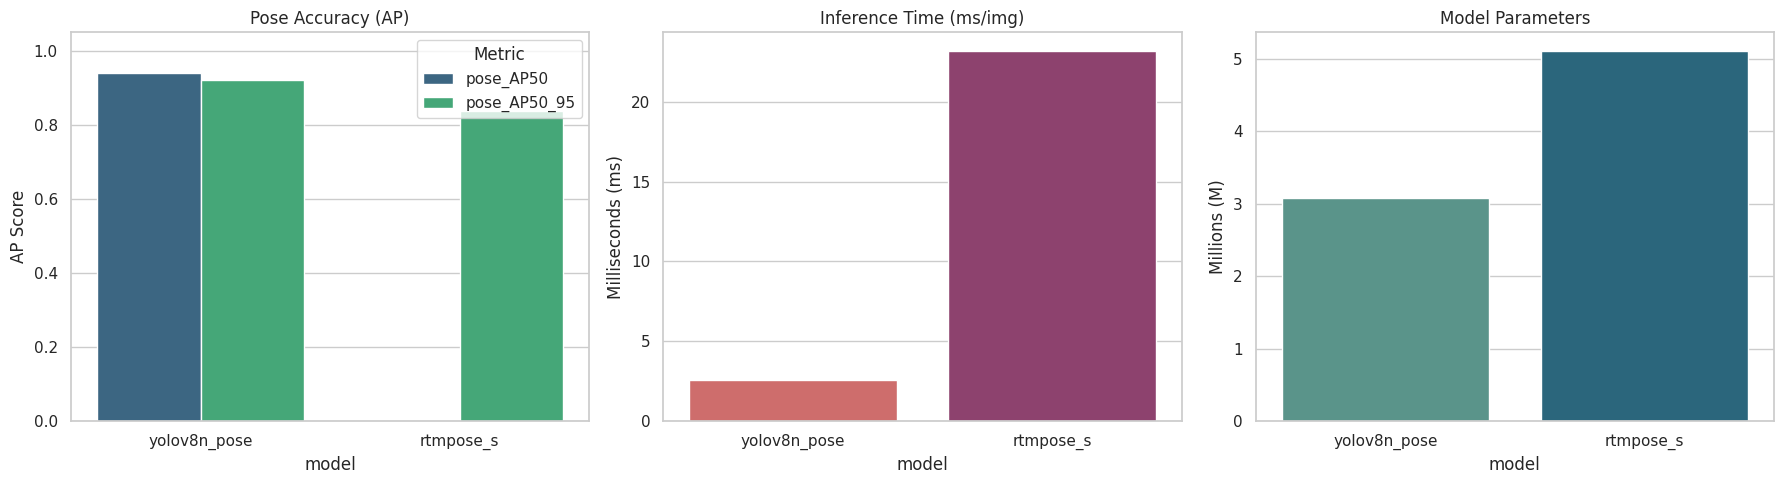

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(_CSV)

# ── pretty-print ──────────────────────────────────────────────────────────────
cols_show = ['model', 'pose_AP50', 'pose_AP50_95',
             'box_AP50', 'box_AP50_95',
             'params_M', 'size_MB',
             'stopped_epoch', 'train_min', 'inf_ms_GPU']
df_show = df[cols_show].copy()
df_show = df_show.rename(columns={
    'pose_AP50':    'Pose AP50',
    'pose_AP50_95': 'Pose AP50:95',
    'box_AP50':     'Box AP50',
    'box_AP50_95':  'Box AP50:95',
    'params_M':     'Params (M)',
    'size_MB':      'Size (MB)',
    'stopped_epoch':'Stopped Ep.',
    'train_min':    'Train (min)',
    'inf_ms_GPU':   'Inf. ms/img',
})

print(df_show.to_string(index=False))
print(f"\n[saved] {_CSV}")

# ── Visualization ─────────────────────────────────────────────────────────────
if not df.empty:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Pose AP (Accuracy)
    df_melt = df.melt(id_vars='model', value_vars=['pose_AP50', 'pose_AP50_95'],
                      var_name='Metric', value_name='Score')
    sns.barplot(data=df_melt, x='model', y='Score', hue='Metric', ax=axes[0], palette='viridis')
    axes[0].set_title('Pose Accuracy (AP)')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('AP Score')

    # 2. Inference Speed
    sns.barplot(data=df, x='model', y='inf_ms_GPU', ax=axes[1], palette='flare')
    axes[1].set_title('Inference Time (ms/img)')
    axes[1].set_ylabel('Milliseconds (ms)')

    # 3. Model Size (Parameters)
    sns.barplot(data=df, x='model', y='params_M', ax=axes[2], palette='crest')
    axes[2].set_title('Model Parameters')
    axes[2].set_ylabel('Millions (M)')

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
# from mmpose.apis import init_model, inference_topdown, inference_bottomup

# ── 1. Load Ground Truth ───────────────────────────────────────────────────────
GT_PATH = '/content/ground_truth.json'
with open(GT_PATH, 'r') as f:
    ground_truth = json.load(f)

# ── 2. Initialize Models ───────────────────────────────────────────────────────
# Classification Model
CLS_MODEL_PATH = f'{DRIVE}/Classifications/yolov8n-cls.pt' # Adjust if needed
cls_model = YOLO(CLS_MODEL_PATH) if Path(CLS_MODEL_PATH).exists() else None

# Pose Models
yolo_pose_model = YOLO(f'{OUT}/yolov8n_pose/weights/best.pt')
# rtm_model = init_model(rtm_cfg_test, f'{OUT}/rtmpose_s/best_coco_AP_epoch_X.pth', device='cuda:0')
# hrn_model = init_model(hrn_cfg_test, f'{OUT}/higherhrnet_w32/best_coco_AP_epoch_Y.pth', device='cuda:0')

# ── 3. Pipeline Functions ──────────────────────────────────────────────────────
def detect_aruco_and_warp(image):
    # TODO: Implement cv2.aruco detection and cv2.warpPerspective
    # Returns warped image
    return image

def get_poses(image, model, model_type='yolo'):
    if model_type == 'yolo':
        results = model(image, verbose=False)
        # Extract keypoints: [[x1, y1], [x2, y2]] per instance
        if len(results) > 0 and results[0].keypoints is not None:
            return results[0].keypoints.xy.cpu().numpy()
    elif model_type == 'rtmpose':
        # TODO: run inference_topdown (requires bounding boxes first)
        pass
    elif model_type == 'higherhrnet':
        # TODO: run inference_bottomup
        pass
    return []

def crop_and_align(image, keypoints):
    crops = []
    for kpts in keypoints:
        if len(kpts) >= 2:
            pt1, pt2 = kpts[0], kpts[1]
            # Calculate angle and distance between pt1 and pt2
            # Rotate and crop image
            # ... placeholder for alignment ...
            # crops.append(aligned_crop)
    return crops

def classify_resistance(crops):
    results = []
    if cls_model is None: return results
    for crop in crops:
        res = cls_model(crop, verbose=False)
        # Extract top class
        top1 = res[0].probs.top1
        results.append(res[0].names[top1])
    return results

def map_to_grid_and_compare(predictions, gt_data):
    # TODO: Map localized points to grid cells
    # Compare predicted resistances/connections with ground truth
    pass

# ── 4. Evaluation Loop ─────────────────────────────────────────────────────────
print("Evaluating models...")
for img_name, gt_info in ground_truth.items():
    img_path = f'{YOLO_DATA}/images/test/{img_name}'
    if not Path(img_path).exists(): continue

    img = cv2.imread(img_path)
    warped_img = detect_aruco_and_warp(img)

    print(f"\nProcessing {img_name}...")
    for model_name, model_obj, m_type in [
        ('YOLOv8n-pose', yolo_pose_model, 'yolo'),
        # ('RTMPose-s', rtm_model, 'rtmpose'),
        # ('HigherHRNet-w32', hrn_model, 'higherhrnet')
    ]:
        poses = get_poses(warped_img, model_obj, model_type=m_type)
        crops = crop_and_align(warped_img, poses)
        classes = classify_resistance(crops)

        print(f"[{model_name}] Found {len(poses)} components. Classes: {classes}")
        # map_to_grid_and_compare(...)